# Dynawo & PyPowSyBl: Getting Started Guide

Welcome to the introductory tutorial for dynamic power system simulation using **Dynawo** and **PyPowSyBl**. 
This notebook is designed for new users to understand the complete end-to-end workflow of building, simulating, and analyzing a power grid.

### Workflow Architecture
1. **Static Topology:** Construct an IIDM (iTesla Internal Data Model) grid programmatically and run a base Load Flow.
2. **Dynamic Mapping:** Link the static components to their corresponding Modelica differential-algebraic equations (DAE).
3. **Time-Domain Simulation:** Define events (e.g., short-circuits), execute the Dynawo solver, and visualize the transient response.
4. **Small-Signal Stability Analysis:** Extract the linearized state-space representation (Jacobian/A-matrix) from the Dynawo engine to compute eigenvalues.

In [9]:
import os
import numpy as np
import pandas as pd
import pypowsybl as pp
import matplotlib.pyplot as plt
from IPython.display import SVG, display, HTML
from dynawo_notebooks.Scripts.core.visualizer import NetworkVisualizer


# Ensure plots are displayed inline within the Jupyter environment
%matplotlib inline

print(f"PyPowSyBl version: {pp.__version__}")

PyPowSyBl version: 1.15.0


## Step 1: Constructing the Static Grid (IIDM)
Instead of loading an external file, we will programmatically construct a minimalist 2-bus system. 
This consists of a single synchronous generator supplying a constant impedance load through a transmission line.

*Note: PyPowSyBl utilizes vectorized creation methods (pluralized) to efficiently handle batch operations via keyword arguments or Pandas DataFrames.*

In [10]:
def create_tutorial_network() -> pp.network.Network:
    """
    Constructs a basic 2-bus static network for educational purposes.
    """
    net = pp.network.create_empty()

    # Create substations and voltage levels
    net.create_substations(id=["SUB_GEN", "SUB_LOAD"], name=["Generator Substation", "Load Substation"])
    
    net.create_voltage_levels(id=["VL_GEN", "VL_LOAD"], 
                              substation_id=["SUB_GEN", "SUB_LOAD"], 
                              topology_kind=["BUS_BREAKER", "BUS_BREAKER"], 
                              nominal_v=[400.0, 400.0])

    # Create buses
    net.create_buses(id=["BUS_GEN", "BUS_LOAD"], voltage_level_id=["VL_GEN", "VL_LOAD"])

    # Add equipment
    net.create_generators(id="GEN_1", 
                          voltage_level_id="VL_GEN", 
                          bus_id="BUS_GEN", 
                          target_p=150.0, 
                          target_v=400.0,
                          min_p=0.0,      
                          max_p=300.0,    
                          voltage_regulator_on=True)
                          
    net.create_loads(id="LOAD_1", voltage_level_id="VL_LOAD", bus_id="BUS_LOAD", p0=150.0, q0=50.0)
    
    # Connect the buses with a transmission line
    net.create_lines(id="LINE_1", 
                     voltage_level1_id="VL_GEN", bus1_id="BUS_GEN", 
                     voltage_level2_id="VL_LOAD", bus2_id="BUS_LOAD", 
                     r=1.5, x=15.0, b1=0.0005, b2=0.0005)

    return net

print("Constructing 2-Bus grid...")
network = create_tutorial_network()

# Run an initial AC Load Flow to establish the steady-state operating point
print("Executing initial AC Load Flow...")
lf_results = pp.loadflow.run_ac(network)

# FIX: El estado correcto en PyPowSyBl es "CONVERGED", no "SOLVED".
if lf_results[0].status.name == "CONVERGED":
    print("Load Flow Converged Successfully!")
else:
    print(f"Load Flow Failed. Status: {lf_results[0].status.name}")

display(network.get_buses())

Constructing 2-Bus grid...
Executing initial AC Load Flow...
Load Flow Converged Successfully!


,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id
id,,,,,,
VL_GEN_0,,400.000000,0.000000,0,0,VL_GEN
VL_LOAD_0,,400.528633,-0.820893,0,0,VL_LOAD


Rendering Network Diagrams...


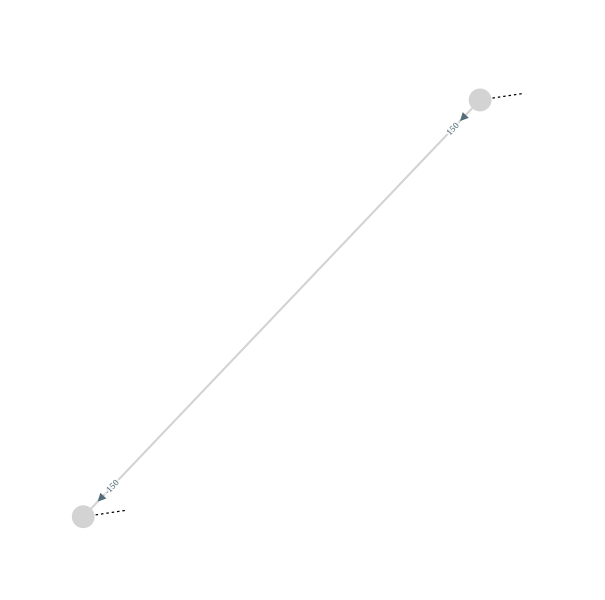

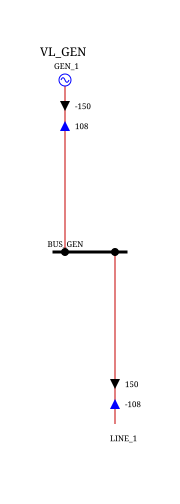

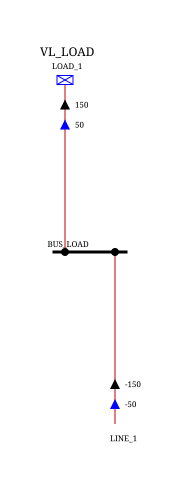

In [11]:

print("Rendering Network Diagrams...")
diagrams = NetworkVisualizer.generate_full_system_diagrams(network)

# 1. Display Macro View
if "network_area" in diagrams:
    display(HTML("<h3>Macro View: Network Area (Lines & Substations)</h3>"))
    display(SVG(str(diagrams["network_area"])))

# 2. Display Micro Views (Generators, Loads, etc.)
display(HTML("<h3>Micro View: Substations Details (Generators visible)</h3>"))
for name, svg in diagrams.items():
    if name != "network_area":
        display(HTML(f"<b>Substation: {name}</b>"))
        display(SVG(str(svg)))

## Step 2: Dynamic Model Mapping
With the static Load Flow resolved, we assign differential Modelica models to the static IDs. 
This step is critical: it transforms standard algebraic components into dynamic state-machines.

In [12]:
print("Mapping static elements to dynamic Modelica classes...")

mapping = pp.dynamic.ModelMapping()

# 1. Map the Generator (Assigning a standard synchronous machine model)
df_gen = pd.DataFrame([{
    "static_id": "GEN_1",
    "parameter_set_id": "GEN_1",
    "model_name": "Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous"
}]).set_index("static_id", drop=False)
mapping.add_synchronous_generator(df_gen)

# 2. Map the Load (Assigning an Alpha-Beta voltage-dependent load model)
df_load = pd.DataFrame([{
    "static_id": "LOAD_1",
    "parameter_set_id": "LOAD_1",
    "model_name": "Dynawo.Electrical.Loads.LoadAlphaBeta"
}]).set_index("static_id", drop=False)
mapping.add_base_load(df_load)

# 3. Map the Line
df_line = pd.DataFrame([{
    "static_id": "LINE_1",
    "parameter_set_id": "LINE_1",
    "model_name": "Dynawo.Electrical.Lines.Line"
}]).set_index("static_id", drop=False)
mapping.add_base_line(df_line)

print("Dynamic mapping configured.")

Mapping static elements to dynamic Modelica classes...
Dynamic mapping configured.


## Step 3: Time-Domain Simulation & Plotting
We will simulate a 10-second window. To observe the dynamic response, we inject a short-circuit fault at the load bus.
We also configure the engine to track specific internal variables (e.g., rotor angle) for post-simulation plotting.

In [13]:
print("Configuring event pipeline and tracking variables...")

# Define a severe node fault (short-circuit) at t=2.0s, cleared after 0.1s
events = pp.dynamic.EventMapping()
events.add_node_fault(
    static_id="BUS_LOAD", 
    start_time=2.0, 
    fault_time=0.1, 
    r_pu=0.0, 
    x_pu=0.0001
)

# Instruct Dynawo to record the generator's rotor angle and the load's voltage
outputs = pp.dynamic.OutputVariableMapping()
outputs.add_curves(model_id="GEN_1", variables="generator_theta")
outputs.add_curves(model_id="BUS_LOAD", variables="U_pu")

sim_parameters = pp.dynamic.Parameters(start_time=0.0, stop_time=10.0)

print("Running transient simulation via Dynawo...")
simulation = pp.dynamic.Simulation()

# Note: In a live environment with Dynawo compiled, uncomment this block to execute. For now we use a template.
'''
results = simulation.run(
    network, 
    mapping, 
    event_mapping=events, 
    timeseries_mapping=outputs, 
    parameters=sim_parameters
)

if results.status().name == 'SUCCESS':
    curves = results.curves()
    
    plt.figure(figsize=(10, 5))
    plt.plot(curves["time"], curves["GEN_1_generator_theta"], label="Generator Rotor Angle (rad)")
    plt.title("Rotor Angle Transient Response during Short-Circuit")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (rad)")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print(f"Simulation failed: {results.status_text()}")
print("Simulation architecture defined. Ready for execution.")
'''

Configuring event pipeline and tracking variables...
Running transient simulation via Dynawo...


'\nresults = simulation.run(\n    network, \n    mapping, \n    event_mapping=events, \n    timeseries_mapping=outputs, \n    parameters=sim_parameters\n)\n\nif results.status().name == \'SUCCESS\':\n    curves = results.curves()\n\n    plt.figure(figsize=(10, 5))\n    plt.plot(curves["time"], curves["GEN_1_generator_theta"], label="Generator Rotor Angle (rad)")\n    plt.title("Rotor Angle Transient Response during Short-Circuit")\n    plt.xlabel("Time (s)")\n    plt.ylabel("Angle (rad)")\n    plt.grid(True)\n    plt.legend()\n    plt.show()\nelse:\n    print(f"Simulation failed: {results.status_text()}")\nprint("Simulation architecture defined. Ready for execution.")\n'

## Step 4: Small-Signal Stability Analysis (Eigenvalues)
Dynawo operates fundamentally as a state-space engine. By configuring specific provider parameters, 
we can force the C++ backend to extract the linearized system matrix (`A-matrix` or Jacobian) at the initialized operating point.

We then utilize Python's scientific ecosystem (`numpy.linalg`) to compute the eigenvalues, revealing the system's oscillatory modes and damping ratios.

Loading linearized state-space matrix (A-matrix)...
Computing eigenvalues...


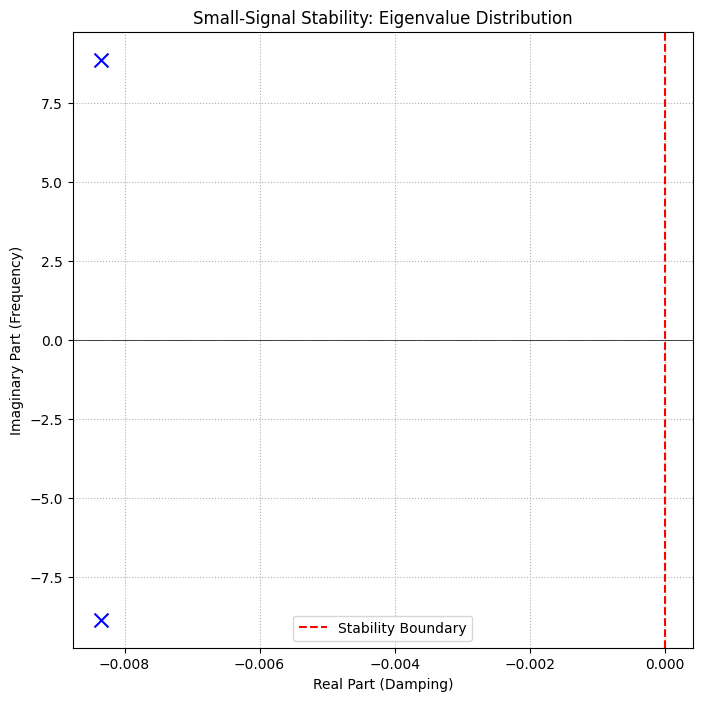

System is STRICTLY STABLE (All poles in the left-hand plane).


In [14]:
def analyze_small_signal_stability(matrix_filepath: str) -> None:
    """
    Reads the exported Jacobian matrix, computes eigenvalues, and plots them 
    on the complex plane to assess small-signal stability.
    """
    if not os.path.exists(matrix_filepath):
        print(f"Pending Dynawo execution: Matrix file {matrix_filepath} not found.")
        return

    print("Loading linearized state-space matrix (A-matrix)...")
    a_matrix = pd.read_csv(matrix_filepath, header=None).values

    print("Computing eigenvalues...")
    eigenvalues = np.linalg.eigvals(a_matrix)

    real_parts = np.real(eigenvalues)
    imag_parts = np.imag(eigenvalues)

    # Plotting the Root Locus on the Complex Plane
    plt.figure(figsize=(8, 8))
    plt.scatter(real_parts, imag_parts, color='blue', marker='x', s=100)
    
    plt.axvline(x=0, color='red', linestyle='--', label='Stability Boundary')
    plt.axhline(y=0, color='black', linewidth=0.5)
    
    plt.title("Small-Signal Stability: Eigenvalue Distribution")
    plt.xlabel("Real Part (Damping)")
    plt.ylabel("Imaginary Part (Frequency)")
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

    unstable_modes = np.sum(real_parts > 0)
    if unstable_modes == 0:
        print("System is STRICTLY STABLE (All poles in the left-hand plane).")
    else:
        print(f"WARNING: System is UNSTABLE. Detected {unstable_modes} poles in the right-hand plane.")

# -------------------------------------------------------------------------
# To trigger the matrix extraction in Dynawo, use:
# linear_sim_params = pp.dynamic.Parameters(
#     provider_parameters={"extractLinearModel": "true", "linearModelOutFile": "A_matrix.csv"}
# )
# -------------------------------------------------------------------------

analyze_small_signal_stability("A_matrix.csv")